# Linear Regression

In [1]:
import numpy as np # Numerical Python Library
import pandas as pd # Data Analysis Library
import matplotlib.pyplot as plt # Plotting Library
from sklearn.linear_model import LinearRegression # Linear Regression Model

#### Students Hour Studied vs Marks Scored (Regression Problem)

Text(0.5, 1.0, 'Students Hour Studied vs Marks Scored')

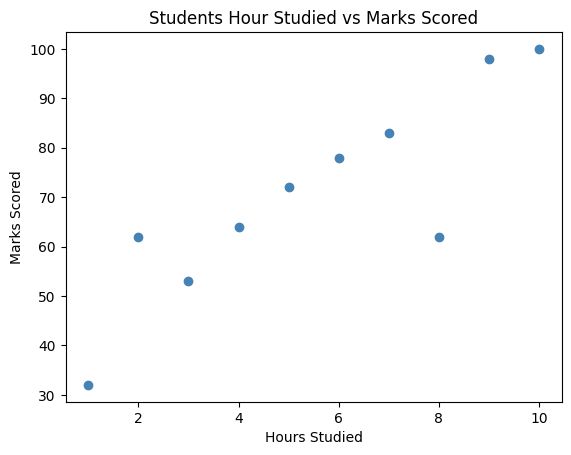

In [8]:
hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1) # Hours Studied
marks = np.array([32, 62, 53, 64, 72, 78, 83, 62, 98, 100]) # Marks Scored
plt.scatter(hours, marks, color='steelblue') # Scatter Plot
plt.xlabel('Hours Studied') # X-axis Label
plt.ylabel('Marks Scored') # Y-axis Label
plt.title('Students Hour Studied vs Marks Scored') # Title

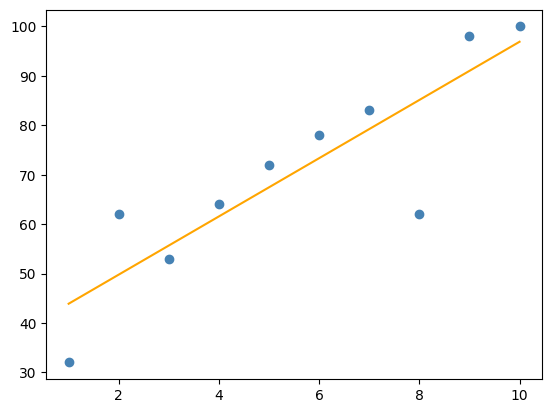

In [9]:
model = LinearRegression() # Create Linear Regression Model
model.fit(hours, marks) # Fit the Model
y_pred = model.predict(hours) # Predict Marks
plt.plot(hours, y_pred, color='orange') # Plot Regression Line
plt.scatter(hours, marks, color='steelblue') # Scatter Plot

In [10]:
print(model.intercept_, model.coef_) # Print Intercept and Coefficient

38.0 [5.89090909]


In [11]:
data = pd.read_csv('https://www.statlearning.com/s/Advertising.csv', index_col=0)
data.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


<Axes: >

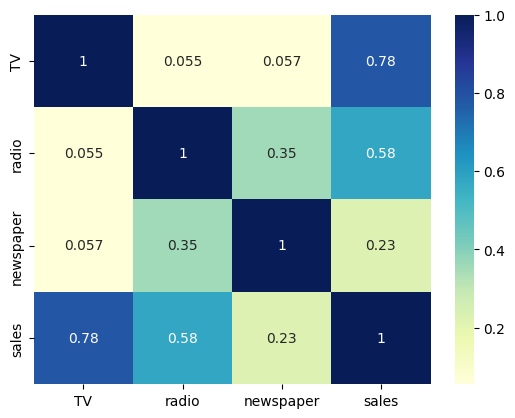

In [15]:
import seaborn as sns # Statistical Data Visualization Library

sns.heatmap(data.corr(), annot=True, cmap='YlGnBu') # Correlation Heatmap

## ML Modeling

In [17]:
X = data.drop('sales', axis=1) # Features
y = data['sales'] # Target Variable

print(X.shape, y.shape) # Print Shape of Features and Target Variable
X.head(2)

(200, 3) (200,)


,TV,radio,newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1


In [18]:
model = LinearRegression() # Create Linear Regression Model
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
print(model.intercept_)
print(model.coef_)

2.9388893694594085
[ 0.04576465  0.18853002 -0.00103749]


In [31]:
data.iloc[4]

TV           180.8
radio         10.8
newspaper     58.4
sales         12.9
Name: 5, dtype: float64

In [32]:
model.predict(data.iloc[4].values[:3].reshape(1, -1))

/Users/aayush/micromamba/envs/stats/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.18867186])

In [35]:
y_pred = model.predict(X) # Predict Sales
model.score(X, y) # R-squared Value

0.8972106381789522

In [36]:
import statsmodels.api as sm # Statistical Models Library

In [38]:
X_with_intercept = sm.add_constant(X) # Add Intercept to Features
model = sm.OLS(y, X_with_intercept).fit()
print(model.summary()) # Print Model Summary

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           1.58e-96
Time:                        08:45:04   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0